# Analisi degli Attacchi Informatici
**Autore:** Cecotti Pietro  
**Corso:** Fondamenti di Data Science e Python Analytics

**Dataset utilizzato:**
- Fonti:
    - Kaggle, dataset "Cybersecurity Attacks",
    - CERT-In (Indian Computer Emergency Response Team)
- Links:
    - [Cybersecurity Attacks](https://www.kaggle.com/datasets/teamincribo/cyber-security-attacks)
    - [CERT-In](https://www.cert-in.org.in)

## Perché questo progetto?
- Comprendere i pattern dei dati per aiutare ad adeguarsi ai trend e prevenire gli attacchi.
- Osservare come i pattern statistici dei sistemi di sicurezza identifichino le anomalie e le vulnerabilità ricorrenti su diversi dispositivi e sistemi.
- Informare sulle varie tipologie di attacchi informatici e come prevenirli.

<div align="center">
  <img src="Foto progetto.png" style="max-height: 400px; width: auto; margin-top: 10px;" alt="Cyber Resilience">
</div>

## Domande principali:
   - Come evolvono gli attacchi nel tempo? Esistono pattern identificabili?
   - Quali sono i Devices, O.S e Borwsers maggiormente colpiti?
   - Quali tipologie di attacco vengono utilizzate?
   - Quali sono i tipi di traffico internet più vulnerabili?
   - Come vengono gestiti e mitigati gli attacchi nelle varie città?
<div align="center">
  <img src="Emoji.png" style="max-height: 150px; width: auto; margin-top: 10px;" alt="Cyber Resilience">
</div>

In [80]:
# Import utili 
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [81]:
# Carichiamo il dataset 
df = pd.read_csv("./dataset/cybersecurity_attacks.csv")

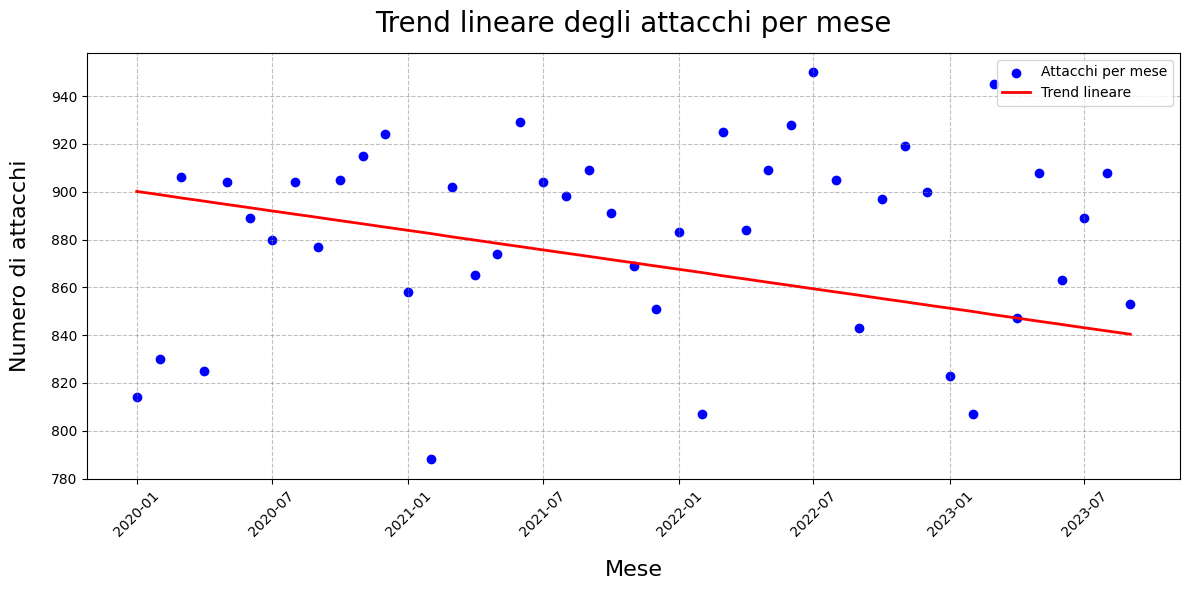

In [82]:
#Estraiamo il periodo in anno + mese 
df['Date'] = pd.to_datetime(df['Timestamp'])
attacks_per_month = df.groupby(df['Date'].dt.to_period('M')).size().reset_index(name='Count')

# Converti il periodo del primo giorno del mese in datetime (rimuovi l'ultimo dato per evitare outliers) 
attacks_per_month['Date'] = attacks_per_month['Date'].dt.to_timestamp().iloc[:-1]

x = np.arange(len(attacks_per_month))  
y = attacks_per_month['Count']

# Regressione lineare
coeffs = np.polyfit(x, y, 1)
poly = np.poly1d(coeffs)

# Grafico
plt.figure(figsize=(12,6))
plt.scatter(attacks_per_month['Date'], y, label="Attacchi per mese", color="blue")
plt.plot(attacks_per_month['Date'], poly(x), color="red", linewidth=2, label="Trend lineare")
plt.grid(True, color='gray', linestyle='--', alpha=0.5)
plt.title("Trend lineare degli attacchi per mese", fontsize=20, pad=15)
plt.xlabel("Mese", fontsize=16, labelpad=15)
plt.ylabel("Numero di attacchi", fontsize=16, labelpad=15)
plt.xticks(rotation=45, fontsize=10)
plt.legend()
plt.tight_layout()
plt.show()


In [83]:
# OS e devieces
devices = [
    'Windows',
    'Linux', 
    'Android',
    'iPad',
    'iPod',
    'iPhone',
    'Macintosh',
]
# Funzione di estrazione
def extract(data):
    if pd.isna(data):
        return 'Unknown'

    data_lower = str(data).lower()
    
    for device in devices:
        if device.lower() in data_lower:
            return device
    return 'Unknown'

# Estrazione dei devices/os e browsers
df['Device/OS'] = df['Device Information'].apply(extract)
df['Browser'] = df['Device Information'].str.split('/').str[0]

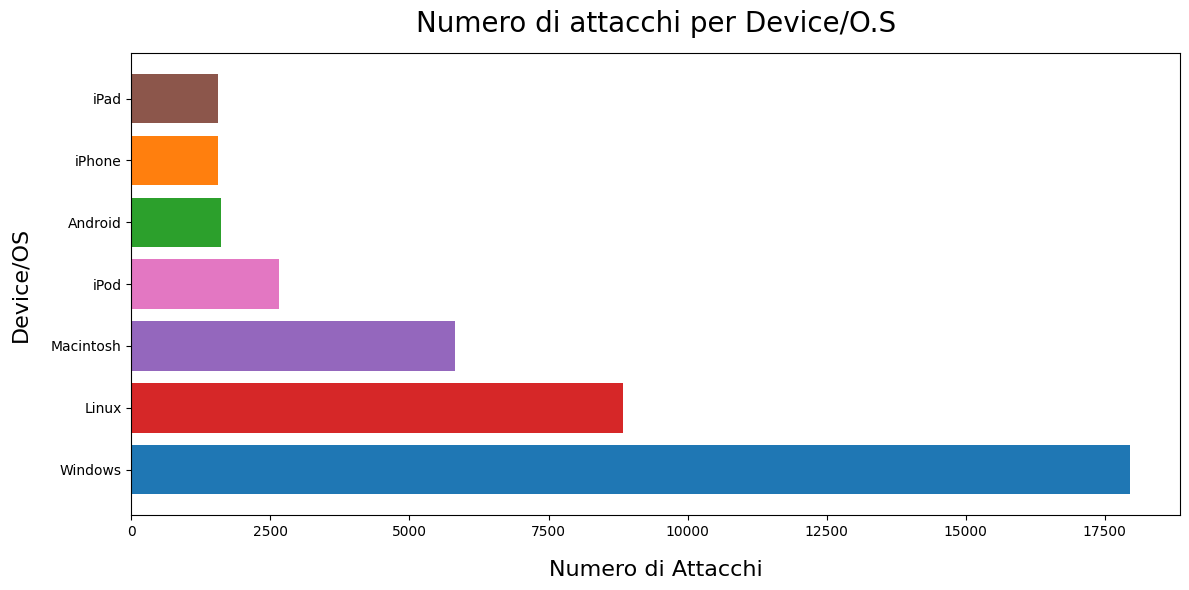

In [84]:
top_devices = df['Device/OS'].value_counts().reset_index()
top_devices.columns = ['Device/OS', 'Count of Attacks']
top_devices = top_devices.head(10)

# Mappa dei colori
color_map = {
    'Windows': '#1f77b4',     # blu
    'Linux': '#d62728',       # verde
    'Android': '#2ca02c',     # rosso
    'iPhone': '#ff7f0e',      # arancione
    'Macintosh': '#9467bd',   # viola
    'iPad': '#8c564b',        # marrone
    'iPod': '#e377c2',        # rosa
    'Unknown': '#7f7f7f'      # grigio
}

# Colori per i top 10
colors = [color_map.get(label, '#17becf') for label in top_devices['Device/OS']]

plt.figure(figsize=(12,6))
bars = plt.barh(top_devices['Device/OS'], top_devices['Count of Attacks'], color=colors)
plt.title("Numero di attacchi per Device/O.S", fontsize=20, pad=15)
plt.xlabel("Numero di Attacchi", fontsize=16, labelpad=15)
plt.ylabel("Device/OS", fontsize=16, labelpad=15)
plt.yticks(fontsize=10),
plt.tight_layout()
plt.show()

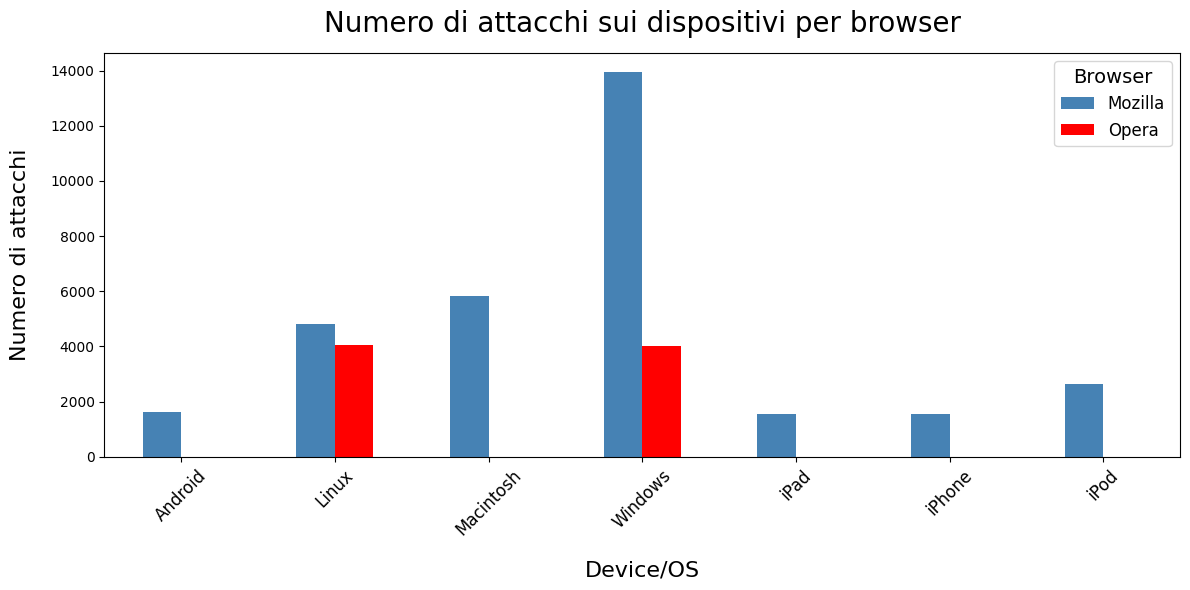

In [85]:
# Raggruppiamo i dati
counts = df.groupby(['Device/OS', 'Browser']).size().unstack(fill_value=0)

# Coloriamo le colonne
colors = []
for browser in counts.columns:
    if browser.lower() == 'opera':
        colors.append('red')
    else:
        colors.append('steelblue')

# Creiamo la figura e gli assi
fig, ax = plt.subplots(figsize=(12, 6))

counts.plot(kind='bar', stacked=False, ax=ax, color=colors)

ax.set_title('Numero di attacchi sui dispositivi per browser', fontsize=20, pad=15)
ax.set_xlabel('Device/OS', fontsize=16, labelpad=15)
ax.set_ylabel('Numero di attacchi', fontsize=16, labelpad=15)
ax.legend(title='Browser', fontsize=12, title_fontsize=14)

plt.xticks(rotation=45, ha='center', fontsize=12)
plt.tight_layout()
plt.show()


### DDoS (Distributed Denial of Service):
Blocca l’accesso ai servizi sovraccaricando i server con traffico massiccio.

Gravità: medio-alta, possono fermare intere infrastrutture.

###  Malware:
Software dannoso che infetta dispositivi per rubare informazioni, crittografare dati o compromettere sistemi.

Gravità: alta, può portare a perdita di dati, furto di informazioni o danni economici.

###  Intrusion:
Accesso non autorizzato a reti o sistemi, spesso per spionaggio, furto di dati o compromissione dei sistemi.

Gravità: molto alta, permette di controllare direttamente le risorse della vittima.

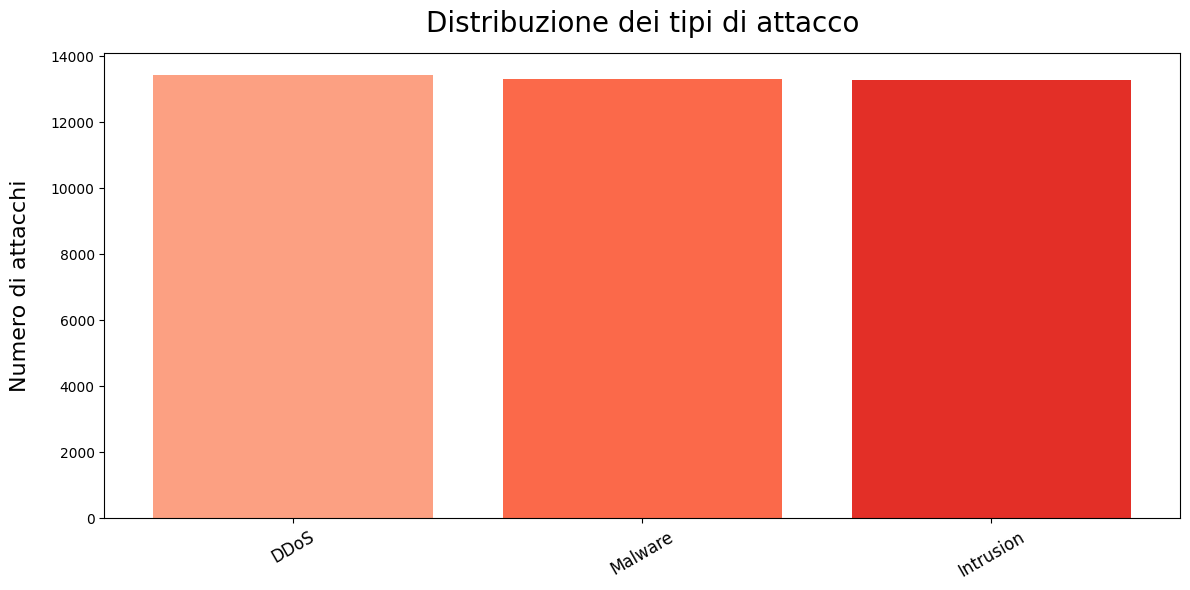

In [86]:
# Conta gli attacchi
attack_counts = df['Attack Type'].value_counts()

red = sns.color_palette("Reds", 5)
colors = [red[1], red[2], red[3]]

plt.figure(figsize=(12,6))
bars = plt.bar(attack_counts.index, attack_counts.values, color=colors)

plt.title("Distribuzione dei tipi di attacco", fontsize=20, pad=15)
plt.ylabel("Numero di attacchi", fontsize=16, labelpad=15)
plt.xticks(rotation=30, ha="center", fontsize=12)
plt.tight_layout()
plt.show()


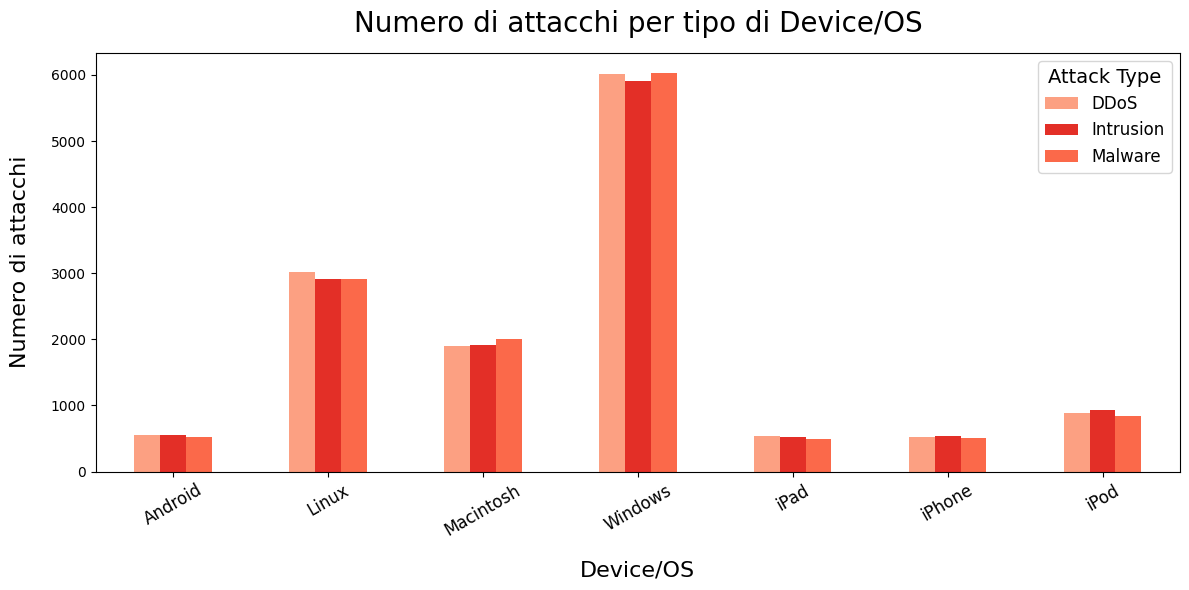

In [87]:
# Raggruppiamo i dati per Device/OS e Attack Type
attacks = df.groupby(['Device/OS', 'Attack Type']).size().unstack(fill_value=0)

red_palette = sns.color_palette("Reds", 5) 
red = red_palette.as_hex()

color_map = {
    "DDoS": red[1], 
    "Malware": red[2],    
    "Intrusion": red[3] 
}

# Ordiniamo i colori
colors = [color_map[elem] for  elem in attacks.columns]

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
attacks.plot(kind='bar', stacked=False, ax=ax, color=colors)

ax.set_title('Numero di attacchi per tipo di Device/OS', fontsize=20, pad=15)
ax.set_xlabel('Device/OS', fontsize=16, labelpad=15)
ax.set_ylabel('Numero di attacchi', fontsize=16, labelpad=15)
ax.legend(title='Attack Type', fontsize=12, title_fontsize=14)

plt.xticks(rotation=30, ha='center', fontsize=12)
plt.tight_layout()
plt.show()

### HTTP (HyperText Transfer Protocol)
Traffico web standard. È il più sfruttato dagli attaccanti, quasi tutti i dispositivi lo usano per navigare e quindi molte possibilità di infezioni o attacchi di phishing.

### DNS (Domain Name System)
Gestisce la traduzione dei nomi di dominio in indirizzi IP. Compromettendo il DNS si possono dirottare gli utenti verso siti malevoli.

### FTP (File Transfer Protocol)
Trasferimento di file tra client e server. Usato meno frequentemente e generalmente protetto meglio, è meno soggetto a infiltrazioni.

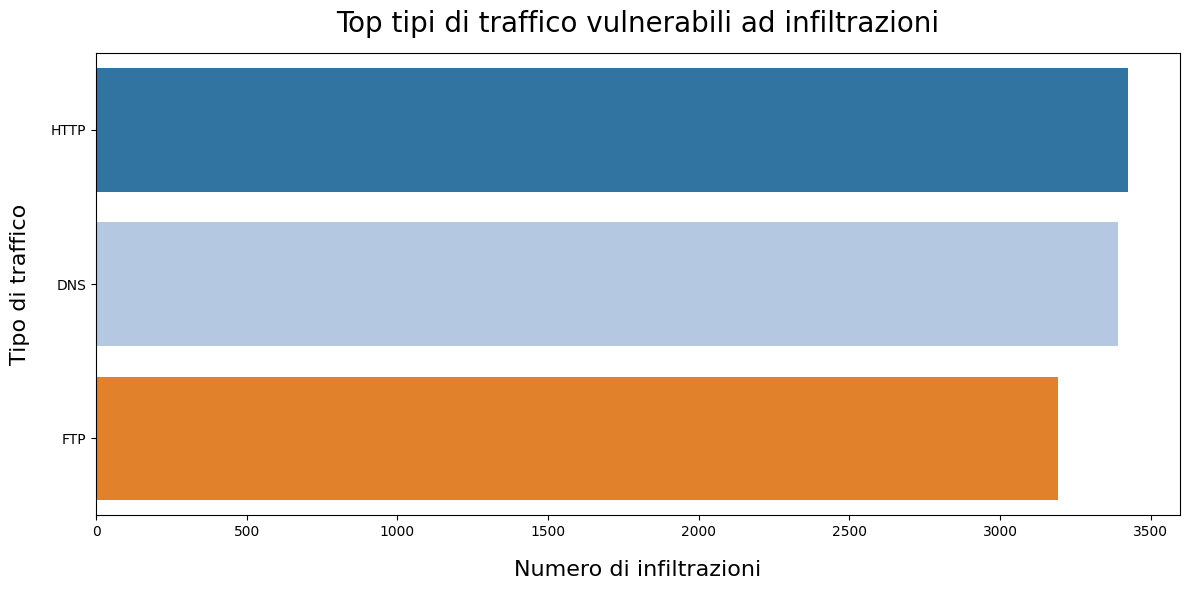

In [88]:
# Calcolo del threshold 
threshold = 75.0  

# Filtro i dati dove l'anomaly score eccede il imite 
infiltration_data = df[df['Anomaly Scores'] > threshold]

# Conto le occorrenze 
vulnerable_traffic_counts = infiltration_data['Traffic Type'].value_counts()

# Creo il dataframe dei traffci vuolnerabili
vulnerable_traffic_df = pd.DataFrame(vulnerable_traffic_counts).reset_index()
vulnerable_traffic_df.columns = ['Traffic Type', 'Count of Infiltrations']

top_vulnerable_traffic = vulnerable_traffic_df

palette = sns.color_palette("tab20", len(top_vulnerable_traffic))

plt.figure(figsize=(12, 6))
sns.barplot(
    x='Count of Infiltrations', 
    y='Traffic Type', 
    data=top_vulnerable_traffic, 
    palette=palette
)

plt.title('Top tipi di traffico vulnerabili ad infiltrazioni', fontsize=20, pad=15)
plt.xlabel('Numero di infiltrazioni', fontsize=16, labelpad=15)
plt.ylabel('Tipo di traffico', fontsize=16, labelpad=15)
plt.tight_layout()
plt.show()

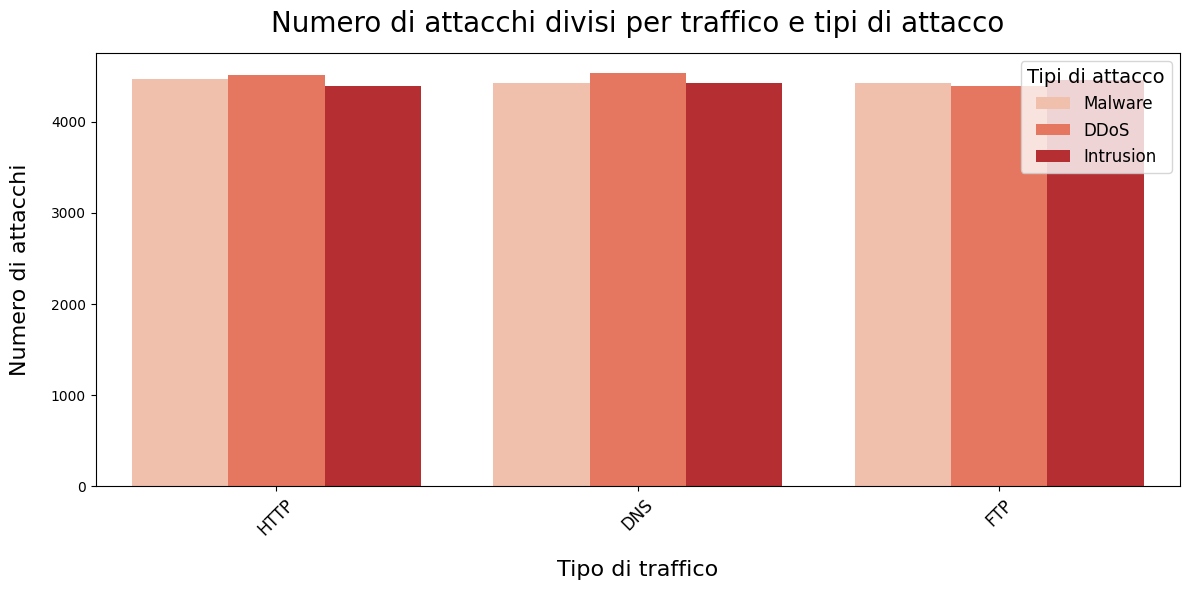

In [89]:
# Plot 
plt.figure(figsize=(12, 6))

ax = sns.countplot(
    data=df, 
    x="Traffic Type", 
    hue="Attack Type", 
    palette="Reds" 
)

plt.title("Numero di attacchi divisi per traffico e tipi di attacco", fontsize=20, pad=15)
plt.xlabel("Tipo di traffico", fontsize=16, labelpad=15)
plt.ylabel("Numero di attacchi", fontsize=16, labelpad=15)
plt.xticks(rotation=45, fontsize=12)
plt.legend(title="Tipi di attacco", fontsize=12, title_fontsize=14)
plt.tight_layout()
plt.show()

### Logged 
L’attacco viene registrato nel sistema, ma non viene bloccato; utile per monitorare attività sospette.

### Ignored 
L’attacco viene ignorato dal sistema, senza azione né registrazione significativa; spesso usato per traffico poco rilevante.

### Blocked 
L’attacco viene attivamente fermato, impedendo l’accesso o la compromissione del sistema; la misura più sicura contro malware e intrusion.

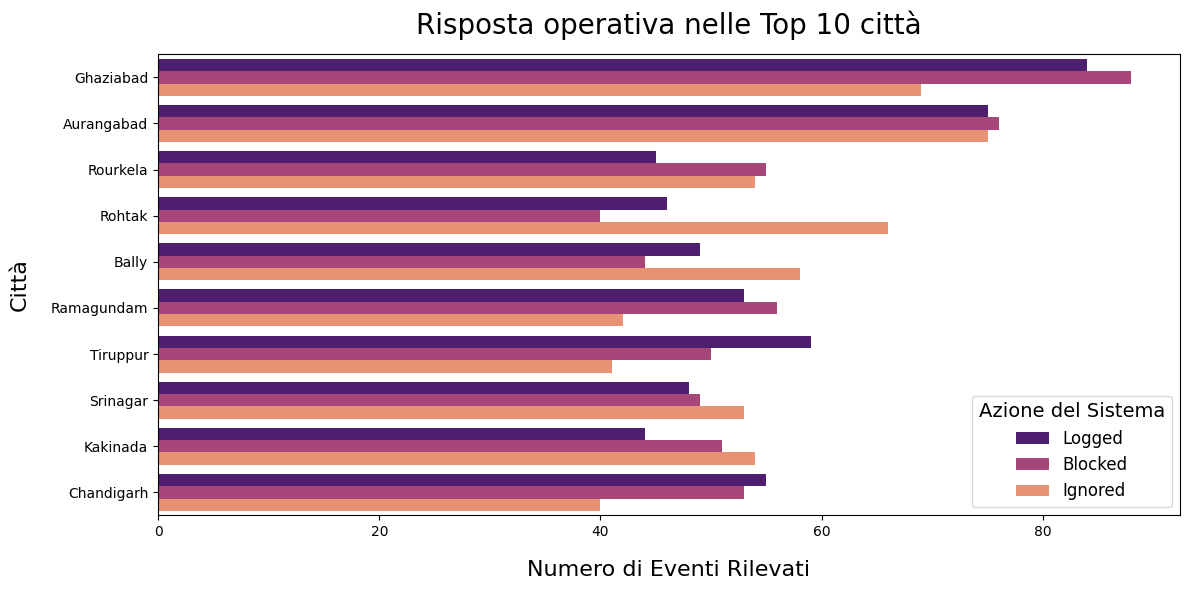

In [90]:
df['City'] = df['Geo-location Data'].str.split(', ').str[0]

# Isoliamo le top 10 città
top_10 = df['City'].value_counts().head(10).index
df_top10 = df[df['City'].isin(top_10)]

# Barplot 
plt.figure(figsize=(12, 6))
sns.countplot(
    data=df_top10,
    y='City',
    hue='Action Taken',  
    order=top_10,
    palette='magma'
)

plt.title("Risposta operativa nelle Top 10 città", fontsize=20, pad=15)
plt.xlabel("Numero di Eventi Rilevati", fontsize=16, labelpad=15)
plt.xticks(fontsize=10)
plt.ylabel("Città", fontsize=16, labelpad=15)
plt.yticks(fontsize=10)
plt.legend(title="Azione del Sistema", loc="lower right", fontsize=12, title_fontsize=14)
plt.tight_layout()
plt.show()

## Strategie di prevenzione e mitigazione

- **Protezione degli endpoint (Windows/Linux):**
  - Implementazione di patch sulla sicurezza e monitoring.

- **Sicurezza di rete e traffico Web (HTTP/DNS):**
  - Adozione di Firewall con rilevamento bot e analisi anti-spoofing.
  - Implementazione di filtering per mitigare attacchi di reindirizzamento e phishing su DNS.
  - Passaggio da FTP a SFTP per protocolli cifrati.

- **Sicurezza per dispositivi personali:**
  - Obbligo di autenticazione a due fattori e VPN cifrate per accessi a wifi esterni.
  - Rigorosi aggiornamenti sulla sicurezza per dispositivi personali.

- **Resilienza infrastrutturale:**
    - Approccio multilivello con architettura zero-trust e backup immutabili.

## Conclusioni

  - I dati mostrano stabilità complessiva con lievi flessioni di fondo e picchi ciclici.

  - Forte asimmetria degli attacchi su Windows dovuta alla predominanza di mercato, seguito da Linux nel comparto server e prevalenza di attacchi sul browser Mozilla sui dispositivi.

  - Equilibrio nella distribuzione degli attacchi DDoS, Malware e Intrusion, con proporzioni uniformi su tutti i sistemi       operativi e tipi di traffico web.

  - HTTP e DNS generano il maggior volume di anomalie, confermandosi i vettori primari degli attacchi informatici.

  - Le principali città urbane registrano una ripartizione omogenea tra azioni di blocco, logging e filtraggio.

<div align="center">
  <h1>Grazie per l'attenzione!</h1>
</div>